In [1]:
# All the imports

import numpy as np
import math
from skfem import MeshHex, Basis, asm, condense
from skfem.element import ElementHex1
from skfem.models.poisson import laplace
from skfem.helpers import dot, grad
from skfem import BilinearForm, LinearForm
from skfem.utils import solve
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot
from scipy.sparse.linalg import eigsh, ArpackNoConvergence
import pickle
from scipy.sparse.linalg import splu, LinearOperator, eigsh
from scipy.optimize import curve_fit, brentq, minimize_scalar
import os

In [2]:
# Diffusion coefficient for a M x M checkerboard pattern.
def D_fun(x, M=4, D_max=1.0, D_min=1.0):
    x0 = x[0]; y0 = x[1]; z0 = x[2]
    x_val = (x0 // (1/M)) % 2
    y_val = (y0 // (1/M)) % 2
    z_val = (z0 // (1/M)) % 2
    is_D_max = (x_val == y_val) == z_val
    return np.where(is_D_max, D_max, D_min)

In [3]:
@BilinearForm
def a(u, v, w):
    return (D_fun(w.x, w.M, w.D_max, w.D_min) * dot(grad(u), grad(v))) + (u * v)

In [4]:
@BilinearForm
def mass(u, v, w):
    return u * v

In [5]:
def fix_sign(u):
    j = np.argmax(np.abs(u))   # index of largest-magnitude component
    return u if u[j] >= 0 else -u

# test D_fun

In [6]:
x_list = np.linspace(0,1,9)
y_list = np.linspace(0,1,9)
z_list = np.linspace(0,1,9)
D_matrix = np.zeros((9,9,9))
for i,x in enumerate(x_list):
    for j,y in enumerate(y_list):
        for k,z in enumerate(z_list):
            D_matrix[i,j,k] = D_fun((x,y,z), M=4, D_max=10, D_min=1)
print("D_fun test")

D_fun test


# ChatGPT function for possibly a better nonuniform grid

In [6]:
def graded_points_on_cell(a, b, n, gamma=2.0):
    """
    Make n subintervals on [a,b], clustered near both endpoints.

    gamma = 1 gives uniform spacing.
    gamma > 1 gives stronger clustering near cell boundaries.
    """
    t = np.linspace(0.0, 1.0, n + 1)

    if gamma == 1.0:
        s = t
    else:
        s = np.empty_like(t)

        left = t <= 0.5
        s[left] = 0.5 * (2.0 * t[left])**gamma
        s[~left] = 1.0 - 0.5 * (2.0 * (1.0 - t[~left]))**gamma

    return a + (b - a) * s


def make_graded_axis(mat_r, n_per_material_cell, gamma=2.0):
    """
    Builds a 1D mesh that exactly includes the material interfaces.

    material_edges = [0, 1/4, 1/2, 3/4, 1]
    n_per_material_cell = number of finite elements inside each material cell
    """
    material_edges = np.linspace(0,1,int(2**mat_r + 1))
    pts = []

    for a, b in zip(material_edges[:-1], material_edges[1:]):
        cell_pts = graded_points_on_cell(a, b, n_per_material_cell, gamma=gamma)

        if len(pts) == 0:
            pts.extend(cell_pts)
        else:
            pts.extend(cell_pts[1:])  # avoid duplicating interface node

    return np.array(pts)


In [7]:
# mat_r is the refinement/level of the material discretization
# r is the refinement/level of the finest part of the grid
def eigs_at_level(mat_r, n_per_material_cell, D_max=1.0, D_min=1.0, gamma=3.0, do_plot=False, grid="uniform"):
    if grid == "uniform":
        xs = np.linspace(0, 1, int(n_per_material_cell * 2**mat_r + 1))
        ys = np.linspace(0, 1, int(n_per_material_cell * 2**mat_r + 1))
        zs = np.linspace(0, 1, int(n_per_material_cell * 2**mat_r + 1))
    elif grid == "nonuniform_power_law":
        xs = make_graded_axis(mat_r, n_per_material_cell=n_per_material_cell, gamma=gamma)
        ys = make_graded_axis(mat_r, n_per_material_cell=n_per_material_cell, gamma=gamma)
        zs = make_graded_axis(mat_r, n_per_material_cell=n_per_material_cell, gamma=gamma)
    
    #m = MeshQuad().init_tensor(xs, ys) # uniform grid
    m = MeshHex().init_tensor(xs, ys, zs)
    basis = Basis(m, ElementHex1(), intorder=2)
    A = asm(a, basis, M=int(2**mat_r), D_max=D_max, D_min=D_min)
    A_test = A.toarray()
    M = asm(mass, basis) 

    Boundary_dofs = basis.get_dofs().all()
    A_c, M_c, x0, I = condense(A, M, D=Boundary_dofs)  

    sigma = 0.0
    vals, vecs = eigsh(A_c, k=1, M=M_c, sigma=sigma, which='LM') 

    lambda1 = vals[0]
    u_free = vecs[:, 0]

    u_full = x0.copy()
    u_full[I] = u_free 

    if do_plot:
        # draw the square discretization
        m = MeshHex().init_tensor(xs, ys)
        ax = m.draw()          
        ax.set_aspect('equal')
        plt.show()

        # prepare the solution array
        u_full = fix_sign(u_full)
        flux_solution = u_full.reshape((int(np.sqrt(len(u_full) + 0.1)), int(np.sqrt(len(u_full) + 0.1)), int(np.sqrt(len(u_full) + 0.1)))) # make the flux solution a square matrix
        grid_1D = xs
    

    return lambda1, u_full, u_full.size, u_free.size

In [86]:
# ChatGPT function for estimating p from a curve fit of nonuniform N values
def estimate_p_from_values(N_vals, eigenvals):
    N_vals = np.asarray(N_vals, dtype=float)
    eigenvals = np.asarray(eigenvals, dtype=float)

    def model(N, Q_inf, C, p):
        return Q_inf + C * N**(-p)

    # Initial guesses
    Q_inf_guess = eigenvals[-1]
    C_guess = eigenvals[0] - eigenvals[-1]
    p_guess = 0.5

    popt, pcov = curve_fit(
        model,
        N_vals,
        eigenvals,
        p0=[Q_inf_guess, C_guess, p_guess],
        maxfev=100000
    )

    Q_inf, C, p = popt
    return float(Q_inf), float(C), float(p)

In [9]:
def estimate_p_with_ground_truth(N_vals, eigenvals, true_eigenval):
    N_vals = np.asarray(N_vals, dtype=float)
    eigenvals = np.asarray(eigenvals, dtype=float)

    eigenval_errors = eigenvals - true_eigenval
    p_vals = [-1 * math.log(eigenval_errors[i] /eigenval_errors[i+1] ) / math.log(N_vals[i] / N_vals[i+1]) for i in range(len(eigenvals)-1)]
    return p_vals

# D=3

In [11]:
D_max_list = [3]

# uniform simulation

In [94]:
n_per_cell_list = [2,3,4,5,6,7,8,9,10]
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"n_per_cell": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for n_per_cell in n_per_cell_list: # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, n_per_material_cell=n_per_cell, D_max=D_max, D_min=1.0, do_plot=False, grid="uniform")
        Data_dict_dmax_1["n_per_cell"].append(n_per_cell)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, n_per_cell: {n_per_cell}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 3, n_per_cell: 2, lambda1: 59.19745680719294, full_size: 729, free_size: 343
D_max: 3, n_per_cell: 3, lambda1: 58.151048793345375, full_size: 2197, free_size: 1331
D_max: 3, n_per_cell: 4, lambda1: 57.69249359791198, full_size: 4913, free_size: 3375
D_max: 3, n_per_cell: 5, lambda1: 57.44790993194638, full_size: 9261, free_size: 6859
D_max: 3, n_per_cell: 6, lambda1: 57.29919470341277, full_size: 15625, free_size: 12167
D_max: 3, n_per_cell: 7, lambda1: 57.200718154963816, full_size: 24389, free_size: 19683
D_max: 3, n_per_cell: 8, lambda1: 57.13144058071636, full_size: 35937, free_size: 29791
D_max: 3, n_per_cell: 9, lambda1: 57.08045871424052, full_size: 50653, free_size: 42875
D_max: 3, n_per_cell: 10, lambda1: 57.04161049248614, full_size: 68921, free_size: 59319
DOFs:  [343, 1331, 3375, 6859, 12167, 19683, 29791, 42875, 59319]
eigenvalues:  [59.19745680719294, 58.151048793345375, 57.69249359791198, 57.44790993194638, 57.29919470341277, 57.200718154963816, 57.13144058071636,

# get uniform fit

In [95]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,len(n_per_cell_list)-2):
    # using polynomial fit
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)


lambda_inf estimates from curve fit:  [56.634560365142164, 56.76551020565589, 56.78297921690301, 56.79125031787392, 56.79489834332105, 56.796838590364715, 56.79793538282901]
C estimates from curve fit:  [24.539375747338458, 30.980484294239925, 32.899881130099935, 34.36287527185547, 35.297747492722706, 35.96803749095654, 36.45503028142485]
p estimates from curve fit:  [0.3869895980373503, 0.43194387547132496, 0.4416847605449287, 0.448027200696125, 0.4516470691802715, 0.4540343299765095, 0.455658490870122]


C:\Users\linco\AppData\Local\Temp\ipykernel_76552\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_76552\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


# nonuniform power law simulation

In [38]:
n_per_cell_list = [2,4,6,8,10]
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"n_per_cell": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for n_per_cell in n_per_cell_list: # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, n_per_material_cell=n_per_cell, D_max=D_max, D_min=1.0, gamma=1.5, do_plot=False, grid="nonuniform_power_law")
        Data_dict_dmax_1["n_per_cell"].append(n_per_cell)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, n_per_cell: {n_per_cell}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 3, n_per_cell: 2, lambda1: 59.19745680719291, full_size: 729, free_size: 343
D_max: 3, n_per_cell: 4, lambda1: 57.562205665872035, full_size: 4913, free_size: 3375
D_max: 3, n_per_cell: 6, lambda1: 57.17254438958838, full_size: 15625, free_size: 12167
D_max: 3, n_per_cell: 8, lambda1: 57.0222139871307, full_size: 35937, free_size: 29791
D_max: 3, n_per_cell: 10, lambda1: 56.94822661587646, full_size: 68921, free_size: 59319
DOFs:  [343, 3375, 12167, 29791, 59319]
eigenvalues:  [59.19745680719291, 57.562205665872035, 57.17254438958838, 57.0222139871307, 56.94822661587646]


# get nonuniform power law fit

In [34]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,len(n_per_cell_list)-2):
    # using polynomial fit
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)


lambda_inf estimates from curve fit:  [53.717350006931134, 56.6833883942933, 56.76708203221951]
C estimates from curve fit:  [10.61746605544174, 57.51391712716151, 110.88107381678907]
p estimates from curve fit:  [0.11329330846608217, 0.469976017511716, 0.5534742417556535]


C:\Users\linco\AppData\Local\Temp\ipykernel_76552\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_76552\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


# D=3 Results

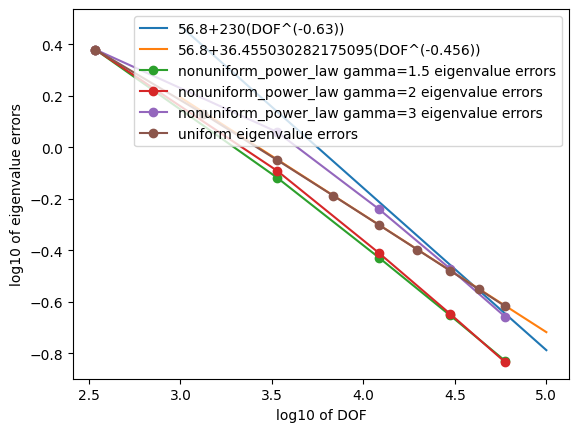

In [39]:
mat_r = 2

# D_max = 3
N_2D_nonuniform_power_law_gamma_15 = np.array([343, 3375, 12167, 29791,  59319])
nonuniform_power_law_eigenvalues_gamma_15 = np.array([59.19745680719291, 57.562205665872035, 57.17254438958838, 57.0222139871307, 56.94822661587646])

N_2D_nonuniform_power_law_gamma_2 = np.array([343, 3375, 12167, 29791,  59319])
nonuniform_power_law_eigenvalues_gamma_2 = np.array([59.19745680719289, 57.61076568392871, 57.1883472282347, 57.02528617768584, 56.946564457386195])

N_2D_nonuniform_power_law_gamma_3 = np.array([343, 3375, 12167, 29791,  59319])
nonuniform_power_law_eigenvalues_gamma_3 = np.array([59.19745680719293, 57.94686989863038, 57.37495604690108, 57.1373930000566, 57.02002207769049])

# uniform data set, D_max=3
N_2D_uniform = [343, 1331, 3375, 6859, 12167, 19683, 29791, 42875, 59319]
uniform_eigenvalues = np.array([59.19745680719291, 58.15104879334536, 57.692493597911955, 57.44790993194638, 57.29919470341277, 57.2007181549638, 57.13144058071638, 57.080458714240486, 57.041610492486086])


############## log plot of eigenvalue error with assumed correct solution #################
true_eigenvalue = 56.8 # "true" infinite discretization eigenvalue from best estimate from looking at fine-mesh eigenvalue results
N_2D_fit = 10**(np.arange(3,6))

p_fit_power_law = 0.63
C_nonuniform_power_law = 230
nonuniform_power_law_asymptotic_fit_error = C_nonuniform_power_law * N_2D_fit**(-1*p_fit_power_law)
plt.plot(np.log10(N_2D_fit), np.log10(nonuniform_power_law_asymptotic_fit_error), label=str(true_eigenvalue) + "+" + str(C_nonuniform_power_law) + "(DOF^(-" + str(p_fit_power_law) + "))")

C_uniform = 36.455030282175095
p_fit = 0.456
uniform_asymptotic_fit_error = C_uniform * N_2D_fit**(-1*p_fit)
plt.plot(np.log10(N_2D_fit), np.log10(uniform_asymptotic_fit_error), label=str(true_eigenvalue) + "+" + str(C_uniform) + "(DOF^(-" + str(p_fit) + "))")

# plot of nonuniform power law eigenvalues vs DOF
plt.plot(np.log10(N_2D_nonuniform_power_law_gamma_15), np.log10(nonuniform_power_law_eigenvalues_gamma_15 - true_eigenvalue), '-o', label="nonuniform_power_law gamma=1.5 eigenvalue errors")
plt.plot(np.log10(N_2D_nonuniform_power_law_gamma_2), np.log10(nonuniform_power_law_eigenvalues_gamma_2 - true_eigenvalue), '-o', label="nonuniform_power_law gamma=2 eigenvalue errors")
plt.plot(np.log10(N_2D_nonuniform_power_law_gamma_3), np.log10(nonuniform_power_law_eigenvalues_gamma_3 - true_eigenvalue), '-o', label="nonuniform_power_law gamma=3 eigenvalue errors")

# plot of uniform eigenvalues vs DOF
plt.plot(np.log10(N_2D_uniform), np.log10(uniform_eigenvalues - true_eigenvalue), '-o', label="uniform eigenvalue errors")
plt.xlabel("log10 of DOF")
plt.ylabel("log10 of eigenvalue errors")
plt.legend()
plt.show()


# D_max = 10

In [44]:
D_max_list = [10]

# Uniform Simulation

In [29]:
n_per_cell_list = [2,3,4,5,6,7,8,9,10]
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"n_per_cell": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for n_per_cell in n_per_cell_list: # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, n_per_material_cell=n_per_cell, D_max=D_max, D_min=1.0, do_plot=False, grid="uniform")
        Data_dict_dmax_1["n_per_cell"].append(n_per_cell)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, n_per_cell: {n_per_cell}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 10, n_per_cell: 2, lambda1: 148.43192945676893, full_size: 729, free_size: 343
D_max: 10, n_per_cell: 3, lambda1: 141.07639720663983, full_size: 2197, free_size: 1331
D_max: 10, n_per_cell: 4, lambda1: 137.48318178875482, full_size: 4913, free_size: 3375
D_max: 10, n_per_cell: 5, lambda1: 135.36283886145273, full_size: 9261, free_size: 6859
D_max: 10, n_per_cell: 6, lambda1: 133.9457445783121, full_size: 15625, free_size: 12167
D_max: 10, n_per_cell: 7, lambda1: 132.92308387444007, full_size: 24389, free_size: 19683
D_max: 10, n_per_cell: 8, lambda1: 132.14530247592052, full_size: 35937, free_size: 29791
D_max: 10, n_per_cell: 9, lambda1: 131.5309213936764, full_size: 50653, free_size: 42875
D_max: 10, n_per_cell: 10, lambda1: 131.03152335911602, full_size: 68921, free_size: 59319
DOFs:  [343, 1331, 3375, 6859, 12167, 19683, 29791, 42875, 59319]
eigenvalues:  [148.43192945676893, 141.07639720663983, 137.48318178875482, 135.36283886145273, 133.9457445783121, 132.92308387444007, 1

# Uniform fit

In [ ]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,len(n_per_cell_list)-2):
    # using polynomial fit
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)


lambda_inf estimates from curve fit:  [126.07144115058993, 126.74983176551015, 126.26551617189608, 125.98281463473032, 133.0047103042116, 125.64391705669566, 125.54880270875364]
C estimates from curve fit:  [124.55222054314154, 133.56645920269688, 123.66980001510109, 117.06770215105244, 223507.60834349197, 107.86398602150038, 104.88325454678511]
p estimates from curve fit:  [0.2941947387245877, 0.3103393302240498, 0.29543092009904953, 0.28575563294586775, 11844.030881239902, 0.27265251556169323, 0.2685225206492234]


C:\Users\linco\AppData\Local\Temp\ipykernel_76552\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_76552\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


# Nonuniform power law simulation

In [55]:
n_per_cell_list = [2,4,6,8,10,12]
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"n_per_cell": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for n_per_cell in n_per_cell_list: # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, n_per_material_cell=n_per_cell, D_max=D_max, D_min=1.0, gamma=4.0, do_plot=False, grid="nonuniform_power_law")
        Data_dict_dmax_1["n_per_cell"].append(n_per_cell)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, n_per_cell: {n_per_cell}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 10, n_per_cell: 2, lambda1: 148.43192945676893, full_size: 729, free_size: 343
D_max: 10, n_per_cell: 4, lambda1: 137.6124012782096, full_size: 4913, free_size: 3375
D_max: 10, n_per_cell: 6, lambda1: 131.80083868198653, full_size: 15625, free_size: 12167
D_max: 10, n_per_cell: 8, lambda1: 129.19244978464226, full_size: 35937, free_size: 29791
D_max: 10, n_per_cell: 10, lambda1: 127.86778835259965, full_size: 68921, free_size: 59319
D_max: 10, n_per_cell: 12, lambda1: 127.11422005659986, full_size: 117649, free_size: 103823
DOFs:  [343, 3375, 12167, 29791, 59319, 103823]
eigenvalues:  [148.43192945676893, 137.6124012782096, 131.80083868198653, 129.19244978464226, 127.86778835259965, 127.11422005659986]


# nonuniform power law fit

In [56]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,len(n_per_cell_list)-2):
    # using polynomial fit
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)


lambda_inf estimates from curve fit:  [-52.89878272570754, 123.15099852882332, 124.78739775350672, 125.10111936114751]
C estimates from curve fit:  [231.82517923428503, 375.2301198566883, 928.140957986448, 1423.469420510234]
p estimates from curve fit:  [0.02415915926342153, 0.4007872858012891, 0.5193604621367667, 0.5680454305772251]


C:\Users\linco\AppData\Local\Temp\ipykernel_76552\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_76552\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


# D_max = 10 results

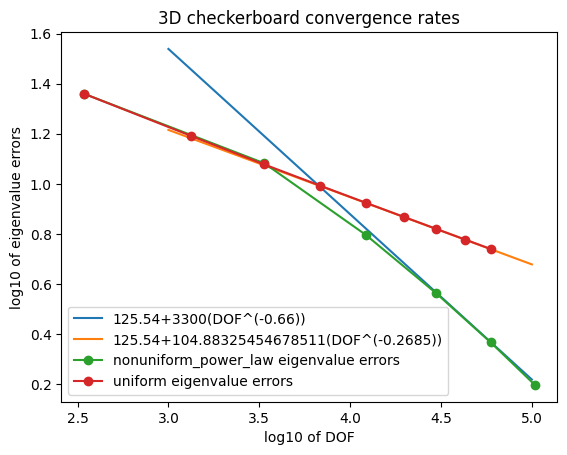

In [82]:
mat_r = 2

# D_max = 3
N_2D_nonuniform_power_law = np.array([343, 3375, 12167, 29791, 59319, 103823])
nonuniform_power_law_eigenvalues = np.array([148.43192945676893, 137.6124012782096, 131.80083868198653, 129.19244978464226, 127.86778835259965, 127.11422005659986])

# uniform data set, D_max=3
N_2D_uniform = [343, 1331, 3375, 6859, 12167, 19683, 29791, 42875, 59319]
uniform_eigenvalues = np.array([148.43192945676893, 141.07639720663983, 137.48318178875482, 135.36283886145273, 133.9457445783121, 132.92308387444007, 132.14530247592052, 131.5309213936764, 131.03152335911602])


############## log plot of eigenvalue error with assumed correct solution #################
true_eigenvalue = 125.54 # "true" infinite discretization eigenvalue from best estimate from looking at fine-mesh eigenvalue results
N_2D_fit = 10**(np.arange(3,6))

p_fit_power_law = 0.66
C_nonuniform_power_law = 3300
nonuniform_power_law_asymptotic_fit_error = C_nonuniform_power_law * N_2D_fit**(-1*p_fit_power_law)
plt.plot(np.log10(N_2D_fit), np.log10(nonuniform_power_law_asymptotic_fit_error), label=str(true_eigenvalue) + "+" + str(C_nonuniform_power_law) + "(DOF^(-" + str(p_fit_power_law) + "))")

C_uniform = 104.88325454678511
p_fit = 0.2685
uniform_asymptotic_fit_error = C_uniform * N_2D_fit**(-1*p_fit)
plt.plot(np.log10(N_2D_fit), np.log10(uniform_asymptotic_fit_error), label=str(true_eigenvalue) + "+" + str(C_uniform) + "(DOF^(-" + str(p_fit) + "))")

# plot of nonuniform power law eigenvalues vs DOF
plt.plot(np.log10(N_2D_nonuniform_power_law), np.log10(nonuniform_power_law_eigenvalues - true_eigenvalue), '-o', label="nonuniform_power_law eigenvalue errors")

# plot of uniform eigenvalues vs DOF
plt.plot(np.log10(N_2D_uniform), np.log10(uniform_eigenvalues - true_eigenvalue), '-o', label="uniform eigenvalue errors")
plt.xlabel("log10 of DOF")
plt.ylabel("log10 of eigenvalue errors")
plt.title("3D checkerboard convergence rates")
plt.legend()
plt.show()


# D_max = 50

In [61]:
D_max_list = [50]

# Uniform Simulation

In [62]:
n_per_cell_list = [2,3,4,5,6,7,8,9,10]
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"n_per_cell": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for n_per_cell in n_per_cell_list: # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, n_per_material_cell=n_per_cell, D_max=D_max, D_min=1.0, do_plot=False, grid="uniform")
        Data_dict_dmax_1["n_per_cell"].append(n_per_cell)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, n_per_cell: {n_per_cell}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 50, n_per_cell: 2, lambda1: 445.9297832870096, full_size: 729, free_size: 343
D_max: 50, n_per_cell: 3, lambda1: 398.62146116532136, full_size: 2197, free_size: 1331
D_max: 50, n_per_cell: 4, lambda1: 381.85966134592405, full_size: 4913, free_size: 3375
D_max: 50, n_per_cell: 5, lambda1: 373.269569278478, full_size: 9261, free_size: 6859
D_max: 50, n_per_cell: 6, lambda1: 367.93013566228154, full_size: 15625, free_size: 12167
D_max: 50, n_per_cell: 7, lambda1: 364.20613993972273, full_size: 24389, free_size: 19683
D_max: 50, n_per_cell: 8, lambda1: 361.4056582804956, full_size: 35937, free_size: 29791
D_max: 50, n_per_cell: 9, lambda1: 359.18741778739627, full_size: 50653, free_size: 42875
D_max: 50, n_per_cell: 10, lambda1: 357.3635202542554, full_size: 68921, free_size: 59319
DOFs:  [343, 1331, 3375, 6859, 12167, 19683, 29791, 42875, 59319]
eigenvalues:  [445.9297832870096, 398.62146116532136, 381.85966134592405, 373.269569278478, 367.93013566228154, 364.20613993972273, 361.40

# Uniform Fit

In [63]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,len(n_per_cell_list)-2):
    # using polynomial fit
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)


lambda_inf estimates from curve fit:  [357.7294577056193, 352.0806942503077, 347.64356233240693, 343.90776168971024, 340.49921487211776, 337.33900847435143, 334.3830226866172]
C estimates from curve fit:  [2413.795233631294, 1469.3118212257139, 938.6760966322478, 647.3675229742578, 475.71142262137516, 371.29193930215536, 305.0003145995108]
p estimates from curve fit:  [0.5668889560926383, 0.47989596322707256, 0.40764559542272, 0.3501764318633338, 0.30331640944940225, 0.26559617455042445, 0.23525984942571954]


C:\Users\linco\AppData\Local\Temp\ipykernel_76552\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_76552\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


# Nonuniform Power Law Simulation

In [75]:
n_per_cell_list = [2,4,6,8,10]
mat_refinement = 2
for D_max in D_max_list:
    Data_dict_dmax_1 = {"n_per_cell": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for n_per_cell in n_per_cell_list: # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, n_per_material_cell=n_per_cell, D_max=D_max, D_min=1.0, gamma=6.0, do_plot=False, grid="nonuniform_power_law")
        Data_dict_dmax_1["n_per_cell"].append(n_per_cell)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, n_per_cell: {n_per_cell}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 50, n_per_cell: 2, lambda1: 445.9297832870094, full_size: 729, free_size: 343
D_max: 50, n_per_cell: 4, lambda1: 418.4610845747187, full_size: 4913, free_size: 3375
D_max: 50, n_per_cell: 6, lambda1: 384.2483298606925, full_size: 15625, free_size: 12167
D_max: 50, n_per_cell: 8, lambda1: 360.01627356670326, full_size: 35937, free_size: 29791
D_max: 50, n_per_cell: 10, lambda1: 344.9721210183792, full_size: 68921, free_size: 59319
DOFs:  [343, 3375, 12167, 29791, 59319]
eigenvalues:  [445.9297832870094, 418.4610845747187, 384.2483298606925, 360.01627356670326, 344.9721210183792]


# Nonuniform Power Law Fit

In [76]:
# get the p values from curve fitting only 3 points at a time
lambda_inf_values_fit = []
C_values_fit = []
p_values_fit = []
for q in range(0,len(n_per_cell_list)-2):
    # using polynomial fit
    lambda_inf, C, p_fit = estimate_p_from_values(Data_dict_dmax_1["free_size"][-3-q:-q], Data_dict_dmax_1["lambda1"][-3-q:-q]) if q != 0 else estimate_p_from_values(Data_dict_dmax_1["free_size"][-3:], Data_dict_dmax_1["lambda1"][-3:])
    lambda_inf_values_fit.append(lambda_inf)
    C_values_fit.append(C)
    p_values_fit.append(p_fit)

# using estimated true eigenvalue for D_max=10: 72.7657004786315
# using estimated true eigenvalue for D_max=10: 20.739
lambda_inf_values_fit = lambda_inf_values_fit[::-1]
C_values_fit = C_values_fit[::-1]
p_values_fit = p_values_fit[::-1]

print("lambda_inf estimates from curve fit: ", lambda_inf_values_fit)
print("C estimates from curve fit: ", C_values_fit)
print("p estimates from curve fit: ", p_values_fit)


lambda_inf estimates from curve fit:  [-216082.41019981008, -222351.90826781568, 271.0991881901509]
C estimates from curve fit:  [216628.48066909082, 222988.49463355282, 1422.6787246379783]
p estimates from curve fit:  [7.698012558645985e-05, 0.00012043389255870006, 0.2691324810598652]


C:\Users\linco\AppData\Local\Temp\ipykernel_76552\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_76552\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


# D=50 Results

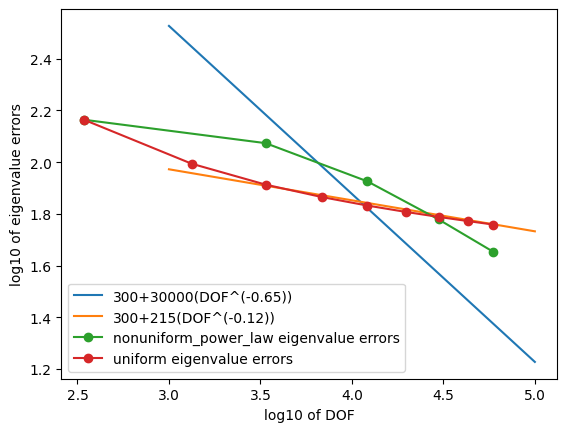

In [81]:
mat_r = 2

# D_max = 3
N_2D_nonuniform_power_law = np.array([343, 3375, 12167, 29791, 59319])
nonuniform_power_law_eigenvalues = np.array([445.9297832870094, 418.4610845747187, 384.2483298606925, 360.01627356670326, 344.9721210183792])

# uniform data set, D_max=3
N_2D_uniform = [343, 1331, 3375, 6859, 12167, 19683, 29791, 42875, 59319]
uniform_eigenvalues = np.array([445.9297832870096, 398.62146116532136, 381.85966134592405, 373.269569278478, 367.93013566228154, 364.20613993972273, 361.4056582804956, 359.18741778739627, 357.3635202542554])


############## log plot of eigenvalue error with assumed correct solution #################
true_eigenvalue = 300 # "true" infinite discretization eigenvalue from best estimate from looking at fine-mesh eigenvalue results
N_2D_fit = 10**(np.arange(3,6))

p_fit_power_law = 0.65
C_nonuniform_power_law = 30000
nonuniform_power_law_asymptotic_fit_error = C_nonuniform_power_law * N_2D_fit**(-1*p_fit_power_law)
plt.plot(np.log10(N_2D_fit), np.log10(nonuniform_power_law_asymptotic_fit_error), label=str(true_eigenvalue) + "+" + str(C_nonuniform_power_law) + "(DOF^(-" + str(p_fit_power_law) + "))")

C_uniform = 215
p_fit = 0.12
uniform_asymptotic_fit_error = C_uniform * N_2D_fit**(-1*p_fit)
plt.plot(np.log10(N_2D_fit), np.log10(uniform_asymptotic_fit_error), label=str(true_eigenvalue) + "+" + str(C_uniform) + "(DOF^(-" + str(p_fit) + "))")

# plot of nonuniform power law eigenvalues vs DOF
plt.plot(np.log10(N_2D_nonuniform_power_law), np.log10(nonuniform_power_law_eigenvalues - true_eigenvalue), '-o', label="nonuniform_power_law eigenvalue errors")

# plot of uniform eigenvalues vs DOF
plt.plot(np.log10(N_2D_uniform), np.log10(uniform_eigenvalues - true_eigenvalue), '-o', label="uniform eigenvalue errors")
plt.xlabel("log10 of DOF")
plt.ylabel("log10 of eigenvalue errors")
plt.legend()
plt.show()


# All 3D simulations

In [10]:
# sz is the number of data points to use per fit
def get_fit_parameters(N_vals, lambda_vals, mat_r, sz=3):
    # get the p values from curve fitting only 3 points at a time
    lambda_inf_values_fit = []
    C_values_fit = []
    p_values_fit = []
    for q in range(0,len(N_vals)-sz+1):
        # using polynomial fit
        lambda_inf, C, p_fit = estimate_p_from_values(N_vals[-sz-q:-q], lambda_vals[-sz-q:-q]) if q != 0 else estimate_p_from_values(N_vals[-sz:], lambda_vals[-sz:])
        lambda_inf_values_fit.append(lambda_inf)
        C_values_fit.append(C)
        p_values_fit.append(p_fit)

    lambda_inf_values_fit = lambda_inf_values_fit[::-1]
    C_values_fit = C_values_fit[::-1]
    p_values_fit = p_values_fit[::-1]

    return lambda_inf_values_fit, C_values_fit, p_values_fit

# uniform simulations

In [82]:
D_max_list = [1,3,10,20,30,40,50]
n_per_cell_list = [2,4,6,8,10,12]
mat_r = 2
for D_max in D_max_list:
    Data_dict = {"n_per_cell": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for n_per_cell in n_per_cell_list: # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, n_per_material_cell=n_per_cell, D_max=D_max, D_min=1.0, do_plot=False, grid="uniform")
        Data_dict["n_per_cell"].append(n_per_cell)
        Data_dict["lambda1"].append(float(lambda1))
        Data_dict["full_size"].append(full_size)
        Data_dict["free_size"].append(free_size)
        Data_dict["u_full"].append(u_full)
        print(f"D_max: {D_max}, n_per_cell: {n_per_cell}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict["free_size"])
    print("eigenvalues: ", Data_dict["lambda1"])

    lambda_inf_values_fit, C_values_fit, p_values_fit = get_fit_parameters(Data_dict["free_size"], Data_dict["lambda1"], mat_r, sz=3)
    print("P values: ", p_values_fit)

D_max: 1, n_per_cell: 2, lambda1: 30.99124196874184, full_size: 729, free_size: 343
D_max: 1, n_per_cell: 4, lambda1: 30.704061035196933, full_size: 4913, free_size: 3375
D_max: 1, n_per_cell: 6, lambda1: 30.651115560123827, full_size: 15625, free_size: 12167
D_max: 1, n_per_cell: 8, lambda1: 30.632602352602923, full_size: 35937, free_size: 29791
D_max: 1, n_per_cell: 10, lambda1: 30.624036501308478, full_size: 68921, free_size: 59319
D_max: 1, n_per_cell: 12, lambda1: 30.61938427466452, full_size: 117649, free_size: 103823
DOFs:  [343, 3375, 12167, 29791, 59319, 103823]
eigenvalues:  [30.99124196874184, 30.704061035196933, 30.651115560123827, 30.632602352602923, 30.624036501308478, 30.61938427466452]
P values:  [0.5944987355056782, 0.622818835671866, 24341.4369014651, 0.6413396261672798]
D_max: 3, n_per_cell: 2, lambda1: 59.19745680719294, full_size: 729, free_size: 343


C:\Users\linco\AppData\Local\Temp\ipykernel_42256\991472087.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)
C:\Users\linco\AppData\Local\Temp\ipykernel_42256\991472087.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


D_max: 3, n_per_cell: 4, lambda1: 57.692493597912, full_size: 4913, free_size: 3375
D_max: 3, n_per_cell: 6, lambda1: 57.29919470341279, full_size: 15625, free_size: 12167
D_max: 3, n_per_cell: 8, lambda1: 57.1314405807164, full_size: 35937, free_size: 29791
D_max: 3, n_per_cell: 10, lambda1: 57.04161049248614, full_size: 68921, free_size: 59319
D_max: 3, n_per_cell: 12, lambda1: 56.98678492900074, full_size: 117649, free_size: 103823
DOFs:  [343, 3375, 12167, 29791, 59319, 103823]
eigenvalues:  [59.19745680719294, 57.692493597912, 57.29919470341279, 57.1314405807164, 57.04161049248614, 56.98678492900074]
P values:  [0.4137754577824103, 0.44634572870609773, 0.45355186719820323, 0.4566048647903312]
D_max: 10, n_per_cell: 2, lambda1: 148.43192945676896, full_size: 729, free_size: 343
D_max: 10, n_per_cell: 4, lambda1: 137.48318178875485, full_size: 4913, free_size: 3375
D_max: 10, n_per_cell: 6, lambda1: 133.94574457831206, full_size: 15625, free_size: 12167
D_max: 10, n_per_cell: 8, lam

# plot uniform results

C:\Users\linco\AppData\Local\Temp\ipykernel_42256\1464798713.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(
C:\Users\linco\AppData\Local\Temp\ipykernel_42256\1464798713.py:7: RuntimeWarning: overflow encountered in power
  return Q_inf + C * N**(-p)


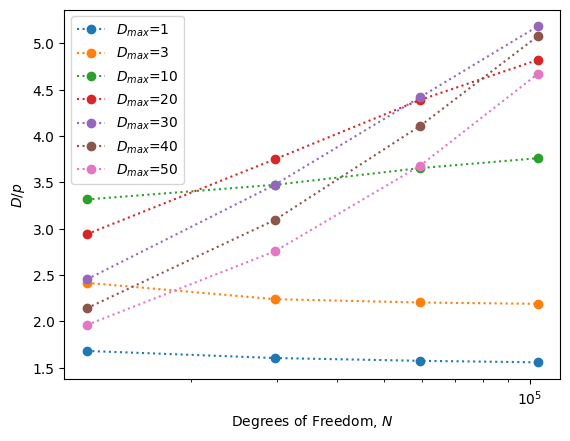

In [87]:
mat_r = 2
fit_size = 3

start_index = 0
level_list = [2,3,4]
N_3D_uniform = [343, 3375, 12167, 29791, 59319, 103823]
D_max_values = [1,3,10,20,30,40,50]

uniform_eigenvalues_1 = np.array([30.991241968741814, 30.70406103519694, 30.651115560123834, 30.63260235260293, 30.624036501308478, 30.619384274664526])
lambda_inf_values_fit_1, C_values_fit_1, p_values_fit_1 = get_fit_parameters(N_3D_uniform, uniform_eigenvalues_1, mat_r, sz=fit_size)
#p_values_fit_1 = get_p_vals(uniform_eigenvalues_1, 8)

uniform_eigenvalues_3 = np.array([59.19745680719291, 57.692493597912, 57.29919470341277, 57.131440580716415, 57.041610492486086, 56.98678492900071])
lambda_inf_values_fit_3, C_values_fit_3, p_values_fit_3 = get_fit_parameters(N_3D_uniform, uniform_eigenvalues_3, mat_r, sz=fit_size)
#p_values_fit_3 = get_p_vals(uniform_eigenvalues_3, 8)

uniform_eigenvalues_10 = np.array([148.43192945676893, 137.48318178875485, 133.94574457831212, 132.1453024759205, 131.03152335911608, 130.2650915304835])
lambda_inf_values_fit_10, C_values_fit_10, p_values_fit_10 = get_fit_parameters(N_3D_uniform, uniform_eigenvalues_10, mat_r, sz=fit_size)
#p_values_fit_10 = get_p_vals(uniform_eigenvalues_10, 8)

uniform_eigenvalues_20 = np.array([258.41331020386417, 230.34091169659445, 221.90345124333265, 217.5067658399633, 214.68548299062857, 212.6715233069367])
lambda_inf_values_fit_20, C_values_fit_20, p_values_fit_20 = get_fit_parameters(N_3D_uniform, uniform_eigenvalues_20, mat_r, sz=fit_size)
#p_values_fit_20 = get_p_vals(uniform_eigenvalues_20, 8)

uniform_eigenvalues_30 = np.array([344.2314274125938, 299.93496759745716, 288.21882251407175, 282.2544660336593, 278.422679613595, 275.6623773297846])
lambda_inf_values_fit_30, C_values_fit_30, p_values_fit_30 = get_fit_parameters(N_3D_uniform, uniform_eigenvalues_30, mat_r, sz=fit_size)
#p_values_fit_30 = get_p_vals(uniform_eigenvalues_30, 8)

uniform_eigenvalues_40 = np.array([405.10516116140116, 348.70064501922343, 335.38106816257016, 328.8609043378205, 324.72878729360286, 321.75968432699136])
lambda_inf_values_fit_40, C_values_fit_40, p_values_fit_40 = get_fit_parameters(N_3D_uniform, uniform_eigenvalues_40, mat_r, sz=fit_size)
#p_values_fit_40 = get_p_vals(uniform_eigenvalues_40, 8)

uniform_eigenvalues_50 = np.array([445.9297832870091, 381.8596613459249, 367.9301356622806, 361.4056582804957, 357.3635202542557, 354.4901463809696])
lambda_inf_values_fit_50, C_values_fit_50, p_values_fit_50 = get_fit_parameters(N_3D_uniform, uniform_eigenvalues_50, mat_r, sz=fit_size)
#p_values_fit_50 = get_p_vals(uniform_eigenvalues_50, 8)


p_values_fit_combined = [p_values_fit_1, p_values_fit_3, p_values_fit_10, p_values_fit_20, p_values_fit_30, p_values_fit_40, p_values_fit_50]

# set a maximum value for the p_value_fit arrays
p_values_fit_combined = [np.clip(p_values_fit_combined[i], a_min=None, a_max=2) for i in range(len(p_values_fit_combined))]

# plot the p values
for i in range(len(p_values_fit_combined)):
    # DOF on x axis
    plt.semilogx(N_3D_uniform[start_index + fit_size - 1:], 1/p_values_fit_combined[i][start_index:], ':o', label=r'$D_{max}$='+str(D_max_values[i]))

    # level on x axis
    #plt.plot(level_list[start_index + fit_size - 1:], p_values_fit_combined[i][start_index:], label="D_max="+str(D_max_values[i]))

#plt.title("D/p vs DOF with uniform mesh")
plt.xlabel(r'Degrees of Freedom, $N$')
plt.ylabel(r"$D/p$")
plt.legend()
plt.show()




In [50]:
D_max_list = [1,3,10,20,30,40,50]
#D_max_list = [3]
gamma_list = [1, 2.1, 3.8, 5, 5.8, 6.2, 6.5]
#gamma_list = [2]
n_per_cell_list = [2,4,6,8,10,12]
mat_refinement = 2
for D_i, D_max in enumerate(D_max_list):
    Data_dict_dmax_1 = {"n_per_cell": [], "lambda1": [], "full_size": [], "free_size": [], "u_full": [], "elements": [], "chi": []}

    for n_per_cell in n_per_cell_list: # grid refinement has to be greater than the material refinement, and min_r being 1 greater than mat_refinement creates the same grid as if min_r is 2 greater so it is skipped
        lambda1, u_full, full_size, free_size = eigs_at_level(mat_r=2, n_per_material_cell=n_per_cell, D_max=D_max, D_min=1.0, gamma=gamma_list[D_i], do_plot=False, grid="nonuniform_power_law")
        Data_dict_dmax_1["n_per_cell"].append(n_per_cell)
        Data_dict_dmax_1["lambda1"].append(float(lambda1))
        Data_dict_dmax_1["full_size"].append(full_size)
        Data_dict_dmax_1["free_size"].append(free_size)
        Data_dict_dmax_1["u_full"].append(u_full)
        print(f"D_max: {D_max}, n_per_cell: {n_per_cell}, lambda1: {lambda1}, full_size: {full_size}, free_size: {free_size}")

    # print and plot eigenvalue results
    print("DOFs: ", Data_dict_dmax_1["free_size"])
    print("eigenvalues: ", Data_dict_dmax_1["lambda1"])

D_max: 1, n_per_cell: 2, lambda1: 30.991241968741825, full_size: 729, free_size: 343
D_max: 1, n_per_cell: 4, lambda1: 30.70406103519694, full_size: 4913, free_size: 3375
D_max: 1, n_per_cell: 6, lambda1: 30.651115560123827, full_size: 15625, free_size: 12167
D_max: 1, n_per_cell: 8, lambda1: 30.632602352602913, full_size: 35937, free_size: 29791
D_max: 1, n_per_cell: 10, lambda1: 30.6240365013085, full_size: 68921, free_size: 59319
D_max: 1, n_per_cell: 12, lambda1: 30.61938427466452, full_size: 117649, free_size: 103823
DOFs:  [343, 3375, 12167, 29791, 59319, 103823]
eigenvalues:  [30.991241968741825, 30.70406103519694, 30.651115560123827, 30.632602352602913, 30.6240365013085, 30.61938427466452]
D_max: 3, n_per_cell: 2, lambda1: 59.19745680719291, full_size: 729, free_size: 343
D_max: 3, n_per_cell: 4, lambda1: 57.63395947554175, full_size: 4913, free_size: 3375
D_max: 3, n_per_cell: 6, lambda1: 57.200538846801415, full_size: 15625, free_size: 12167
D_max: 3, n_per_cell: 8, lambda1: 

# plot nonuniform results

C:\Users\linco\AppData\Local\Temp\ipykernel_42256\1464798713.py:14: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


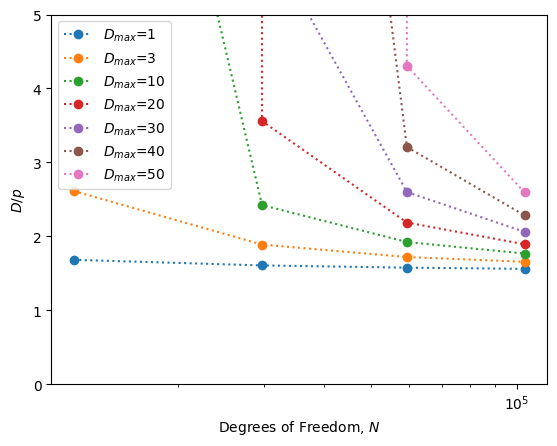

In [89]:
mat_r = 2
fit_size = 3

start_index = 0
level_list = [2,3,4]
N_3D_uniform = [343, 3375, 12167, 29791, 59319, 103823]
D_max_values = [1,3,10,20,30,40,50]

nonuniform_eigenvalues_1 = np.array([30.991241968741825, 30.70406103519694, 30.651115560123827, 30.632602352602913, 30.6240365013085, 30.61938427466452])
lambda_inf_values_fit_1, C_values_fit_1, p_values_fit_1 = get_fit_parameters(N_3D_uniform, nonuniform_eigenvalues_1, mat_r, sz=fit_size)
#p_values_fit_1 = get_p_vals(uniform_eigenvalues_1, 8)

nonuniform_eigenvalues_3 = np.array([59.19745680719291, 57.63395947554175, 57.200538846801415, 57.03218459737055, 56.95088135251948, 56.9056756733695])
lambda_inf_values_fit_3, C_values_fit_3, p_values_fit_3 = get_fit_parameters(N_3D_uniform, nonuniform_eigenvalues_3, mat_r, sz=fit_size)
#p_values_fit_3 = get_p_vals(uniform_eigenvalues_3, 8)

nonuniform_eigenvalues_10 = np.array([148.43192945676898, 137.04612701955028, 131.4679763551324, 128.99790938404917, 127.74427673134676, 127.03022986523379])
lambda_inf_values_fit_10, C_values_fit_10, p_values_fit_10 = get_fit_parameters(N_3D_uniform, nonuniform_eigenvalues_10, mat_r, sz=fit_size)
#p_values_fit_10 = get_p_vals(uniform_eigenvalues_10, 8)

nonuniform_eigenvalues_20 = np.array([258.4133102038641, 235.13745313932657, 217.49742018686854, 208.45150756961107, 203.62261904719367, 200.80611990506483])
lambda_inf_values_fit_20, C_values_fit_20, p_values_fit_20 = get_fit_parameters(N_3D_uniform, nonuniform_eigenvalues_20, mat_r, sz=fit_size)
#p_values_fit_20 = get_p_vals(uniform_eigenvalues_20, 8)

nonuniform_eigenvalues_30 = np.array([344.2314274125938, 317.35207200372474, 289.0762398762553, 272.55543882647044, 263.20589292784933, 257.6030956345334])
lambda_inf_values_fit_30, C_values_fit_30, p_values_fit_30 = get_fit_parameters(N_3D_uniform, nonuniform_eigenvalues_30, mat_r, sz=fit_size)
#p_values_fit_30 = get_p_vals(uniform_eigenvalues_30, 8)

nonuniform_eigenvalues_40 = np.array([405.10516116140155, 378.8965365708884, 345.51125965438297, 323.5096426310371, 310.3074299325555, 302.15539299164584])
lambda_inf_values_fit_40, C_values_fit_40, p_values_fit_40 = get_fit_parameters(N_3D_uniform, nonuniform_eigenvalues_40, mat_r, sz=fit_size)
#p_values_fit_40 = get_p_vals(uniform_eigenvalues_40, 8)

nonuniform_eigenvalues_50 = np.array([445.9297832870096, 423.17175485079065, 389.2451259651319, 364.0176206509405, 347.88722310303393, 337.5920546800919])
lambda_inf_values_fit_50, C_values_fit_50, p_values_fit_50 = get_fit_parameters(N_3D_uniform, nonuniform_eigenvalues_50, mat_r, sz=fit_size)
#p_values_fit_50 = get_p_vals(uniform_eigenvalues_50, 8)


p_values_fit_combined = [p_values_fit_1, p_values_fit_3, p_values_fit_10, p_values_fit_20, p_values_fit_30, p_values_fit_40, p_values_fit_50]

# set a minimum value for the p_value_fit arrays
p_values_fit_combined = [np.clip(p_values_fit_combined[i], a_min=None, a_max=None) for i in range(len(p_values_fit_combined))]

# plot the p values
for i in range(len(p_values_fit_combined)):
    # DOF on x axis
    plt.semilogx(N_3D_uniform[start_index + fit_size - 1:], 1/p_values_fit_combined[i][start_index:], ':o',label=r'$D_{max}$='+str(D_max_values[i]))

    # level on x axis
    #plt.plot(level_list[start_index + fit_size - 1:], p_values_fit_combined[i][start_index:], label="D_max="+str(D_max_values[i]))

#plt.title("D/p vs DOF with nonuniform mesh")
plt.xlabel(r'Degrees of Freedom, $N$')
plt.ylabel(r"$D/p$")
plt.ylim(0,5)
plt.legend()
plt.show()


